# Next-Word Prediction: GRU

Trains and evaluates a **GRU** model on prepared windows and held-out test sentences.

**Architecture:** `Embedding → GRU → Dropout → Dense → Softmax`

The GRU uses **update and reset gates**, combining cell and hidden states with fewer parameters than LSTM, often resulting in faster training.

**Metrics:** **Top-1**, **Top-5 accuracy**, and **Perplexity** (`exp(cross-entropy)`). Lower perplexity means better prediction confidence.


## 1. Setup

In [1]:
%matplotlib inline
import os
import sys

sys.path.append(os.path.abspath(".."))  # so `import config` and `from src...` work from notebooks/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

import config

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("TensorFlow:", tf.__version__)
print(f"Epochs={config.EPOCHS}  Units={config.UNITS}  EmbedDim={config.EMBED_DIM}  BatchSize={config.BATCH_SIZE}  SeqLen={config.SEQ_LEN}")
print("Corpus:", config.DEFAULT_CORPUS)
print("Outputs:", config.OUTPUTS_DIR)

TensorFlow: 2.21.0
Epochs=8  Units=64  EmbedDim=64  BatchSize=256  SeqLen=5
Corpus: C:\Users\User\Downloads\next-word-prediction (3)\next-word-prediction-main\data\raw\corpus.txt
Outputs: C:\Users\User\Downloads\next-word-prediction (3)\next-word-prediction-main\outputs


## 2. Train

`src.train.train` is the same code path as `python -m src.train --model gru`. It uses early stopping on validation loss, halves the learning rate on plateaus, saves the best checkpoint to `models/gru.keras`, and appends results to `outputs/metrics.json`.

In [2]:
from src.train import train

result = train(
    "gru",
    config.DEFAULT_CORPUS,
    verbose=2,
)

Data: {"vocab_size": 10000, "train_samples": 976755, "val_samples": 120778, "test_samples": 121282, "seq_len": 5}


Model: "next_word_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_dropout (Dropout)         │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_word_probs (Dense)         │ (None, 10000)          │       650,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,960 (5.02 MB)

 Trainable params: 1,314,960 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
3816/3816 - 175s - 46ms/step - loss: 6.6231 - top1_accuracy: 0.0918 - top5_accuracy: 0.2284 - val_loss: 6.1202 - val_top1_accuracy: 0.1263 - val_top5_accuracy: 0.2741 - learning_rate: 0.0010
Epoch 2/8
3816/3816 - 217s - 57ms/step - loss: 6.1162 - top1_accuracy: 0.1233 - top5_accuracy: 0.2731 - val_loss: 5.8459 - val_top1_accuracy: 0.1424 - val_top5_accuracy: 0.3013 - learning_rate: 0.0010
Epoch 3/8
3816/3816 - 202s - 53ms/step - loss: 5.9391 - top1_accuracy: 0.1326 - top5_accuracy: 0.2891 - val_loss: 5.7351 - val_top1_accuracy: 0.1492 - val_top5_accuracy: 0.3111 - learning_rate: 0.0010
Epoch 4/8
3816/3816 - 198s - 52ms/step - loss: 5.8434 - top1_accuracy: 0.1376 - top5_accuracy: 0.2974 - val_loss: 5.6720 - val_top1_accuracy: 0.1519 - val_top5_accuracy: 0.3178 - learning_rate: 0.0010
Epoch 5/8
3816/3816 - 183s - 48ms/step - loss: 5.7733 - top1_accuracy: 0.1410 - top5_accuracy: 0.3030 - val_loss: 5.6205 - val_top1_accuracy: 0.1564 - val_top5_accuracy: 0.3232 - learning_rate: 0.

## 3. Training curves

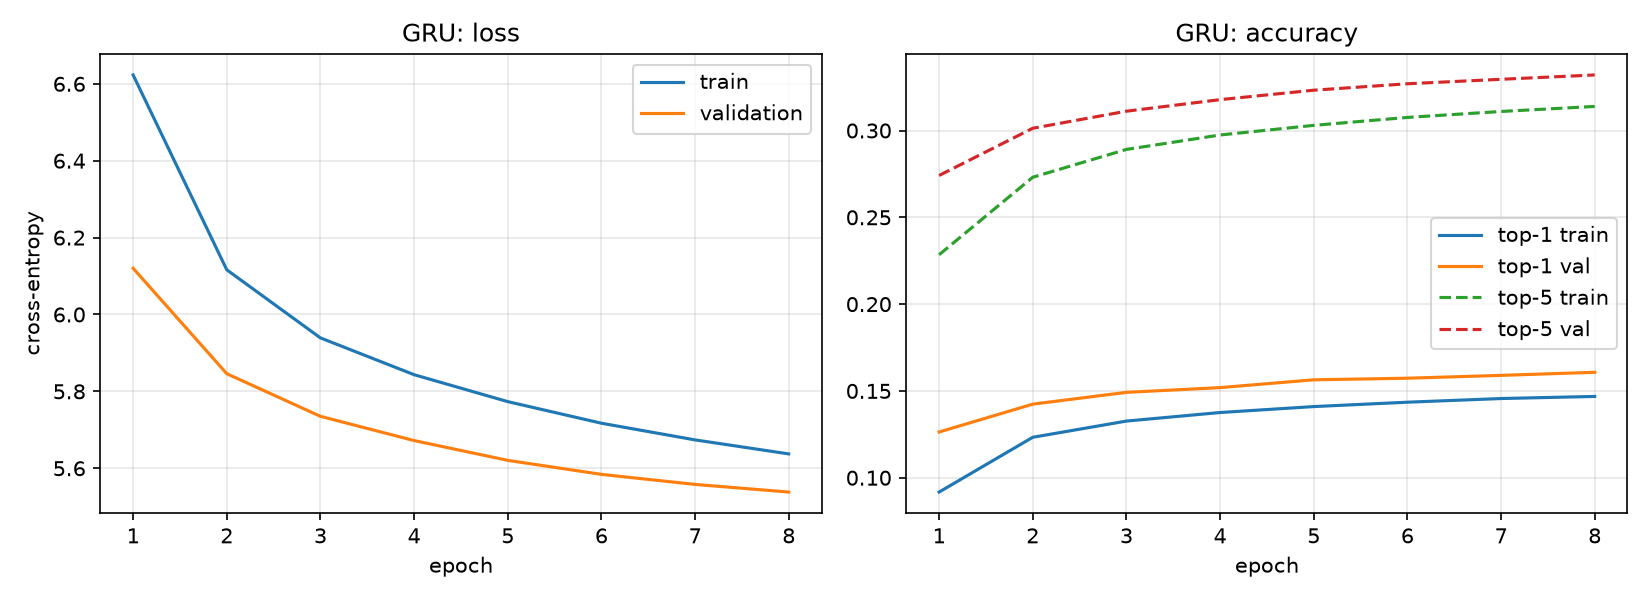

In [3]:
from IPython.display import Image, display

display(Image(filename=str(config.OUTPUTS_DIR / "gru_training_curves.png")))

## 4. Test-set results

In [4]:
pd.Series({k: v for k, v in result.items() if k != "hyperparameters"})

model                gru
parameters       1314960
top1_accuracy     0.1601
top5_accuracy     0.3337
test_loss         5.5334
perplexity        253.01
train_seconds     1535.6
epochs_run             8
best_epoch             8
dtype: object

## 5. Try it

Load the saved model exactly as the web app does.

In [5]:
from src.predict import Predictor

predictor = Predictor.load(config.MODELS_DIR / "gru.keras", config.VOCAB_PATH)

for prompt in ["i want to go to the ", "it is a ", "holmes was ", "what do you "]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(f"{s['word']} ({s['probability']:.0%})" for s in top5))

'i want to go to the '     -> world (1%), same (1%), next (1%), end (1%), house (1%)
'it is a '                 -> good (4%), great (3%), lot (3%), bit (2%), little (2%)
'holmes was '              -> a (9%), the (3%), not (2%), in (2%), on (1%)
'what do you '             -> have (12%), do (7%), know (6%), are (4%), want (4%)


In [6]:
# Mid-word completion, like a keyboard: the last word is unfinished, so we complete it
for prompt in ["i want to g", "it was a very d"]:
    top5 = predictor.predict_next(prompt, k=5)
    print(f"{prompt!r:<26} ->", ", ".join(s["word"] for s in top5))

'i want to g'              -> get, go, give, grow, grab
'it was a very d'          -> difficult, different, dangerous, dark, delicious


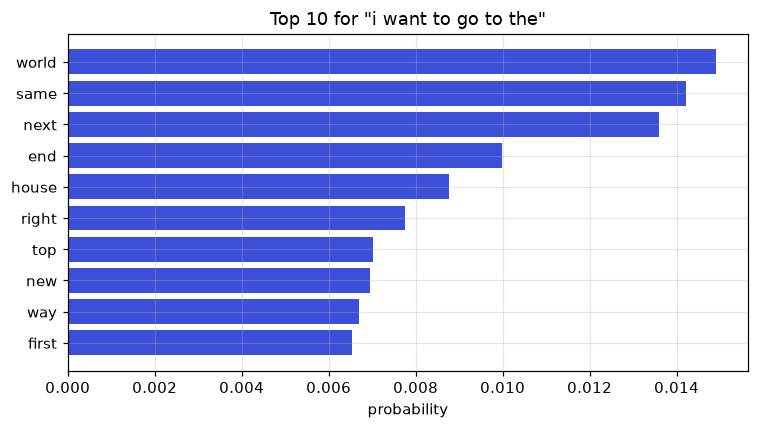

In [7]:
# Probability distribution behind the five suggestions (the last box in the sketch)
%matplotlib inline
prompt = "i want to go to the "
top = predictor.predict_next(prompt, k=10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh([s["word"] for s in top][::-1], [s["probability"] for s in top][::-1], color="#3b4fd8")
ax.set(title=f'Top 10 for "{prompt.strip()}"', xlabel="probability")
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "gru_example_prediction.png")
plt.show()

Next: `05_comparison.ipynb`.